[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Train Soccer Player + Ball Detector (Combined Model)

---

## 🎯 Objetivo: Modelo Único para Jogadores e Bola

Este notebook treina um modelo YOLOv12m que deteta **4 classes** num único passe:
- ⚽ **Ball** - Bola (classe 0)
- 🥅 **Goalkeeper** - Guarda-redes (classe 1)
- 👕 **Player** - Jogadores (classe 2)
- 👔 **Referee** - Árbitros (classe 3)

**⚡ Vantagem de Performance**: Elimina o InferenceSlicer (6-12 inferências/frame → 1 inferência/frame)

**Configuração Híbrida**:
- **imgsz=1088** - Alta resolução para apanhar bola sem slicing
- **copy_paste=0.1** - Aumenta bolas no dataset
- **close_mosaic=10** - Refinamento nas últimas épocas

**Modelo output**: `yolo12m_jogadores_bola_1.pt`

## Configure API keys

- Open your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Fri Mar 13 10:12:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   57C    P0             19W /   94W |    1093MiB /   8188MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

c:\_FOOTAR\PD_FOOTAR\training\notebooks


## 📁 Dataset Local FOOTAR - 👤 PLAYERS/KEEPERS/REFEREES + ⚽ BALL

- Modelo combinado: deteta jogadores, guarda-redes, árbitros **E bola** num único modelo

**🎯 Treino multi-classe COMPLETO (4 classes)**

- **ball (0)** - Bola de futebol
- **goalkeeper (1)** - Guarda-redes
- **player (2)** - Jogadores de campo
- **referee (3)** - Árbitros

**Vantagem**: Elimina necessidade do InferenceSlicer para bola → Melhora FPS significativamente!

In [3]:
import os

# Path to local FOOTAR dataset (4 classes - treinaremos TODAS)
DATASET_PATH = r"C:\_FOOTAR\PD_FOOTAR\training\datasets\football-players-and-ball"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print(f"✅ Dataset path: {DATASET_PATH}")
print(f"🎯 CLASSES A TREINAR: ball, goalkeeper, player, referee (TODAS as 4 classes)")
print(f"⚡ Vantagem: Um único modelo para tudo → elimina slicer → mais FPS!")

print(f"✅ data.yaml: {DATA_YAML}")
print(f"✅ Dataset exists: {os.path.exists(DATA_YAML)}")

✅ Dataset path: C:\_FOOTAR\PD_FOOTAR\training\datasets\football-players-and-ball
🎯 CLASSES A TREINAR: ball, goalkeeper, player, referee (TODAS as 4 classes)
⚡ Vantagem: Um único modelo para tudo → elimina slicer → mais FPS!
✅ data.yaml: C:\_FOOTAR\PD_FOOTAR\training\datasets\football-players-and-ball\data.yaml
✅ Dataset exists: True


## 📊 Dataset Info

**Dataset FOOTAR**: `football-players-and-ball-1`
- **4 classes**: ball, goalkeeper, player, referee
- **TODAS treinadas** neste modelo

- **708** imagens de treino

**🎯 Objetivo**: Modelo único que deteta:
- ⚽ **Ball** (bola de futebol) - com copy_paste augmentation
- 🥅 **Goalkeeper** (guarda-redes com equipamento diferente)
- 👕 **Player** (jogadores de campo)
- 👔 **Referee** (árbitros com equipamento distinto)

**⚡ Abordagem Híbrida**: 
- **imgsz=1088** - Resolução alta para ver a bola claramente
- **copy_paste=0.1** - Cola bolas extra para balancear classes
- **close_mosaic=10** - Desliga mosaic no fim para afinação
- **scale=0.3** - Protege objetos pequenos de ficarem micro

**Estimativa de Performance**: de ~1.7 FPS → 15-25 FPS (elimina slicer)

In [4]:
import yaml

# Read data.yaml
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("📋 Dataset Configuration:")
print(f"  Classes: {data_config['nc']}")
print(f"  Names: {data_config['names']}")
print(f"  Train: {data_config['train']}")
print(f"  Val: {data_config['val']}")
print(f"  Test: {data_config['test']}")

# Verify paths exist
train_path = os.path.join(DATASET_PATH, "train", "images")
val_path = os.path.join(DATASET_PATH, "valid", "images")
print(f"\n✅ Train images: {len(os.listdir(train_path))}")
print(f"✅ Val images: {len(os.listdir(val_path))}")

📋 Dataset Configuration:
  Classes: 4
  Names: ['ball', 'goalkeeper', 'player', 'referee']
  Train: train/images
  Val: valid/images
  Test: test/images

✅ Train images: 708
✅ Val images: 202


## Custom training - YOLOv12m (Medium - 4 Classes)

**⚡ CONFIGURAÇÃO HÍBRIDA: Simples nos cálculos, Específica nos dados**

**Modelo & Hardware:**
- 🎯 **Model: yolo12m** - 26M parâmetros (Medium - bom equilíbrio precisão/velocidade)
- ✅ **epochs: 100** - Mais tempo para convergência
- ✅ **imgsz: 1088** - Resolução alta (múltiplo de 32) para apanhar a bola sem slicing
- ✅ **batch: 4** - Baixo para caber nos 8GB VRAM
- ✅ **amp: True** - Mixed precision (poupa VRAM e acelera)

**Classes (4 - TODAS):**
- ⚽ **Ball** - Bola (classe 0)
- 🥅 **Goalkeeper** - Guarda-redes (classe 1)
- 👕 **Player** - Jogadores de campo (classe 2)
- 👔 **Referee** - Árbitros (classe 3)

**Data Augmentation para Objetos Pequenos:**
- ✅ **mosaic: 1.0** - Junta 4 imagens (excelente contexto)
- ✅ **mixup: 0.1** - Sobrepõe imagens (ajuda no desequilíbrio)
- ✅ **copy_paste: 0.1** - Cola bolas noutros sítios do campo
- ✅ **scale: 0.3** - Protege a bola de ser encolhida demais

**Afinação Final:**
- ✅ **patience: 20** - Early stopping se não houver melhorias
- ✅ **close_mosaic: 10** - Imagens reais nas últimas 10 épocas

**NOTA:** Optimizer, LRs e perdas são calculados automaticamente pelo YOLO.

**Nome do modelo final:** `yolo12m_jogadores_bola_1`

In [5]:
import gc
import torch

# 🧹 LIMPEZA CRÍTICA: Liberta VRAM presa do treino anterior
gc.collect()
torch.cuda.empty_cache()

# Verifica memória disponível
print(f"✅ VRAM limpa!")
print(f"📊 Memória GPU livre: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
print(f"📊 Memória GPU total: {torch.cuda.mem_get_info()[1] / 1024**3:.2f} GB")
print("\n⚠️ Se ainda mostrar 0 bytes livres, REINICIA O KERNEL (Ctrl+Shift+P → 'Restart Kernel')\n")

✅ VRAM limpa!
📊 Memória GPU livre: 6.93 GB
📊 Memória GPU total: 8.00 GB

⚠️ Se ainda mostrar 0 bytes livres, REINICIA O KERNEL (Ctrl+Shift+P → 'Restart Kernel')



In [ ]:
import os
import gc
import torch
from ultralytics import YOLO

# VRAM cleanup before training
gc.collect()
torch.cuda.empty_cache()

# Download and initialize YOLOv12m pretrained model (MEDIUM - bom equilíbrio)
model = YOLO('yolo12m.pt')

# Start training with YOLOv12m configuration
# RTX 4060 Laptop 8GB optimized settings - ALL 4 CLASSES
results = model.train(
    data=DATA_YAML,
    epochs=100,
    
    # 1. RESOLUÇÃO (Corrigido para múltiplo de 32)
    imgsz=1088,        # Alta resolução para apanhar a bola sem slicing
    batch=4,           # Baixo para caber nos 8GB VRAM
    device=0,
    
    # 2. DATA AUGMENTATION INTELIGENTE (objetos pequenos)
    mosaic=1.0,        # Junta 4 imagens (excelente contexto)
    mixup=0.1,         # Sobrepõe imagens (ajuda no desequilíbrio)
    copy_paste=0.1,    # Cola bolas noutros sítios do campo
    scale=0.3,         # Protege a bola de ser encolhida demais
    
    # 3. PERFORMANCE E VRAM
    workers=4,         # Usa 4 núcleos do CPU
    amp=True,          # Mixed precision (poupa VRAM e acelera)
    cache=False,       # False se não tens muita RAM
    
    # 4. AFINAÇÃO FINAL
    patience=20,       # Para cedo se não houver melhorias
    close_mosaic=10,   # Imagens reais nas últimas 10 épocas
    
    # 5. OUTPUT
    project='runs/detect',
    name='yolo12m_jogadores_bola_1',
    val=True,
    plots=True
    
    # NOTA: Optimizer, LRs e perdas são calculados automaticamente pelo YOLO
    # baseado no data.yaml (número de classes, tamanho do dataset, etc.)
)

Ultralytics 8.4.21  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\_FOOTAR\PD_FOOTAR\training\datasets\football-players-and-ball\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1088, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12m_jogadores_bola_1, nbs=64, nms=False, opse

In [ ]:
# Get the run directory path
RUN_DIR = results.save_dir
print(f"📁 Run directory: {RUN_DIR}")
print(f"📊 Training complete!")
print(f"🏆 Best model saved at: {os.path.join(RUN_DIR, 'weights', 'best.pt')}")

📁 Run directory: C:\_FOOTAR\PD_FOOTAR\training\notebooks\runs\detect\runs\detect\yolo12m_jogadores_bola
📊 Training complete!
🏆 Best model saved at: C:\_FOOTAR\PD_FOOTAR\training\notebooks\runs\detect\runs\detect\yolo12m_jogadores_bola\weights\best.pt


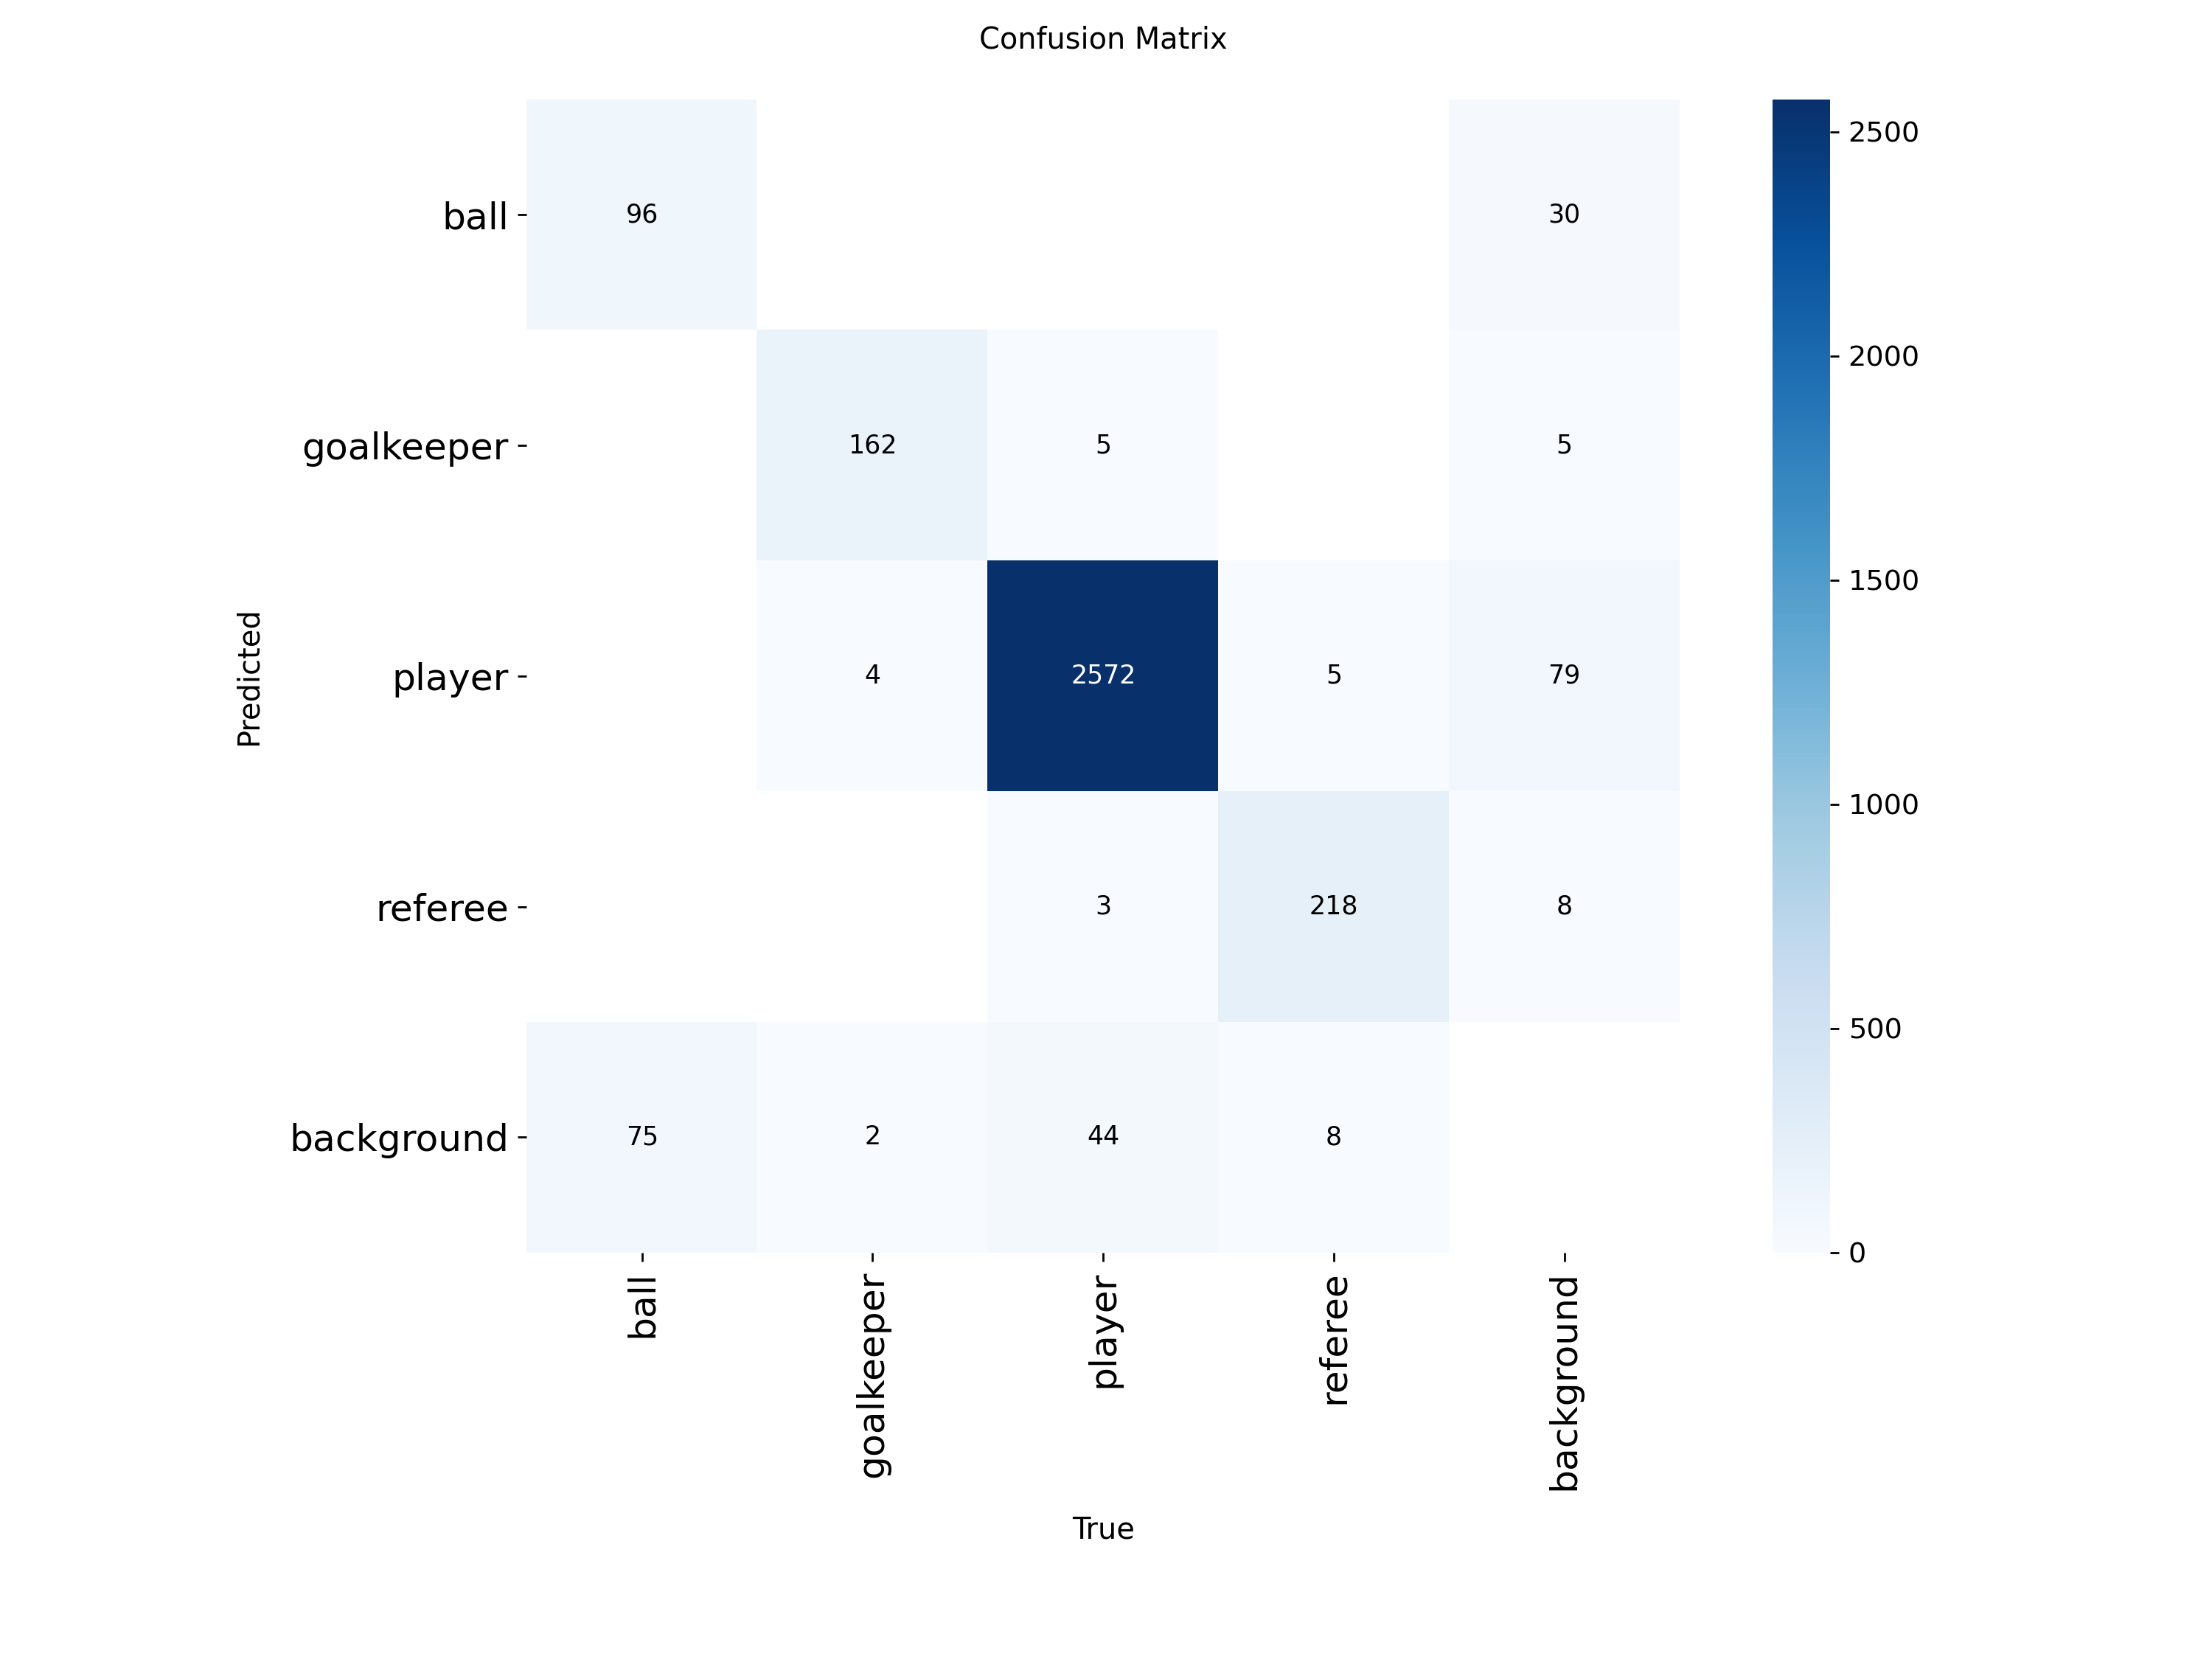

In [ ]:
from IPython.display import Image, display
# Mostra matriz de confusão
display(Image(filename=f"{RUN_DIR}/confusion_matrix.png", width=600))

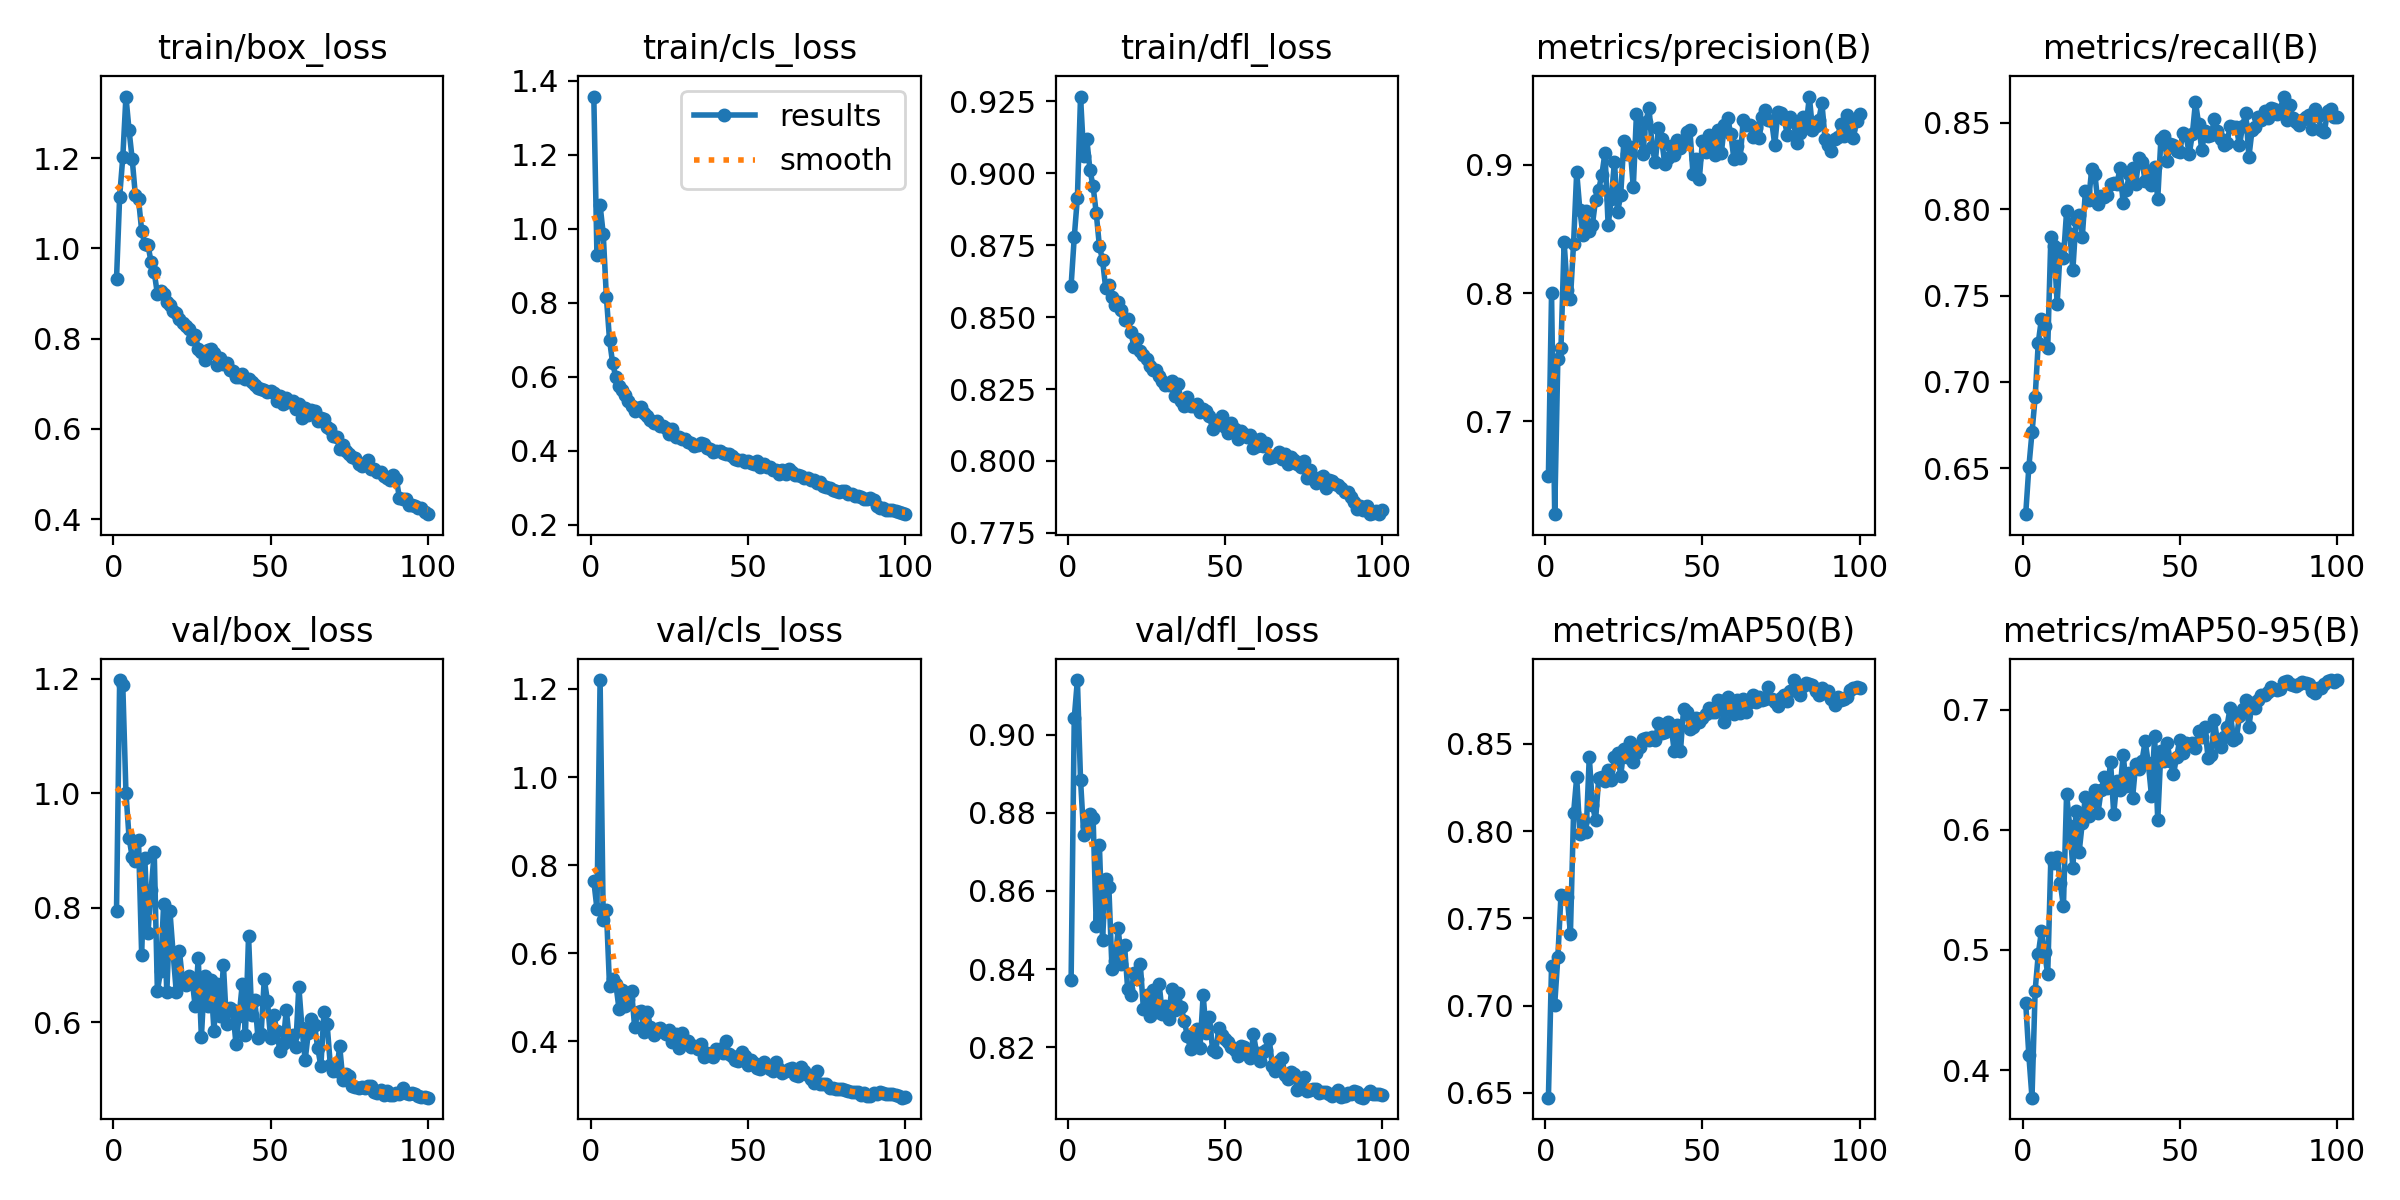

In [ ]:
from IPython.display import Image, display
# Mostra gráfico de resultados (losses/mAP)
display(Image(filename=f"{RUN_DIR}/results.png", width=600))

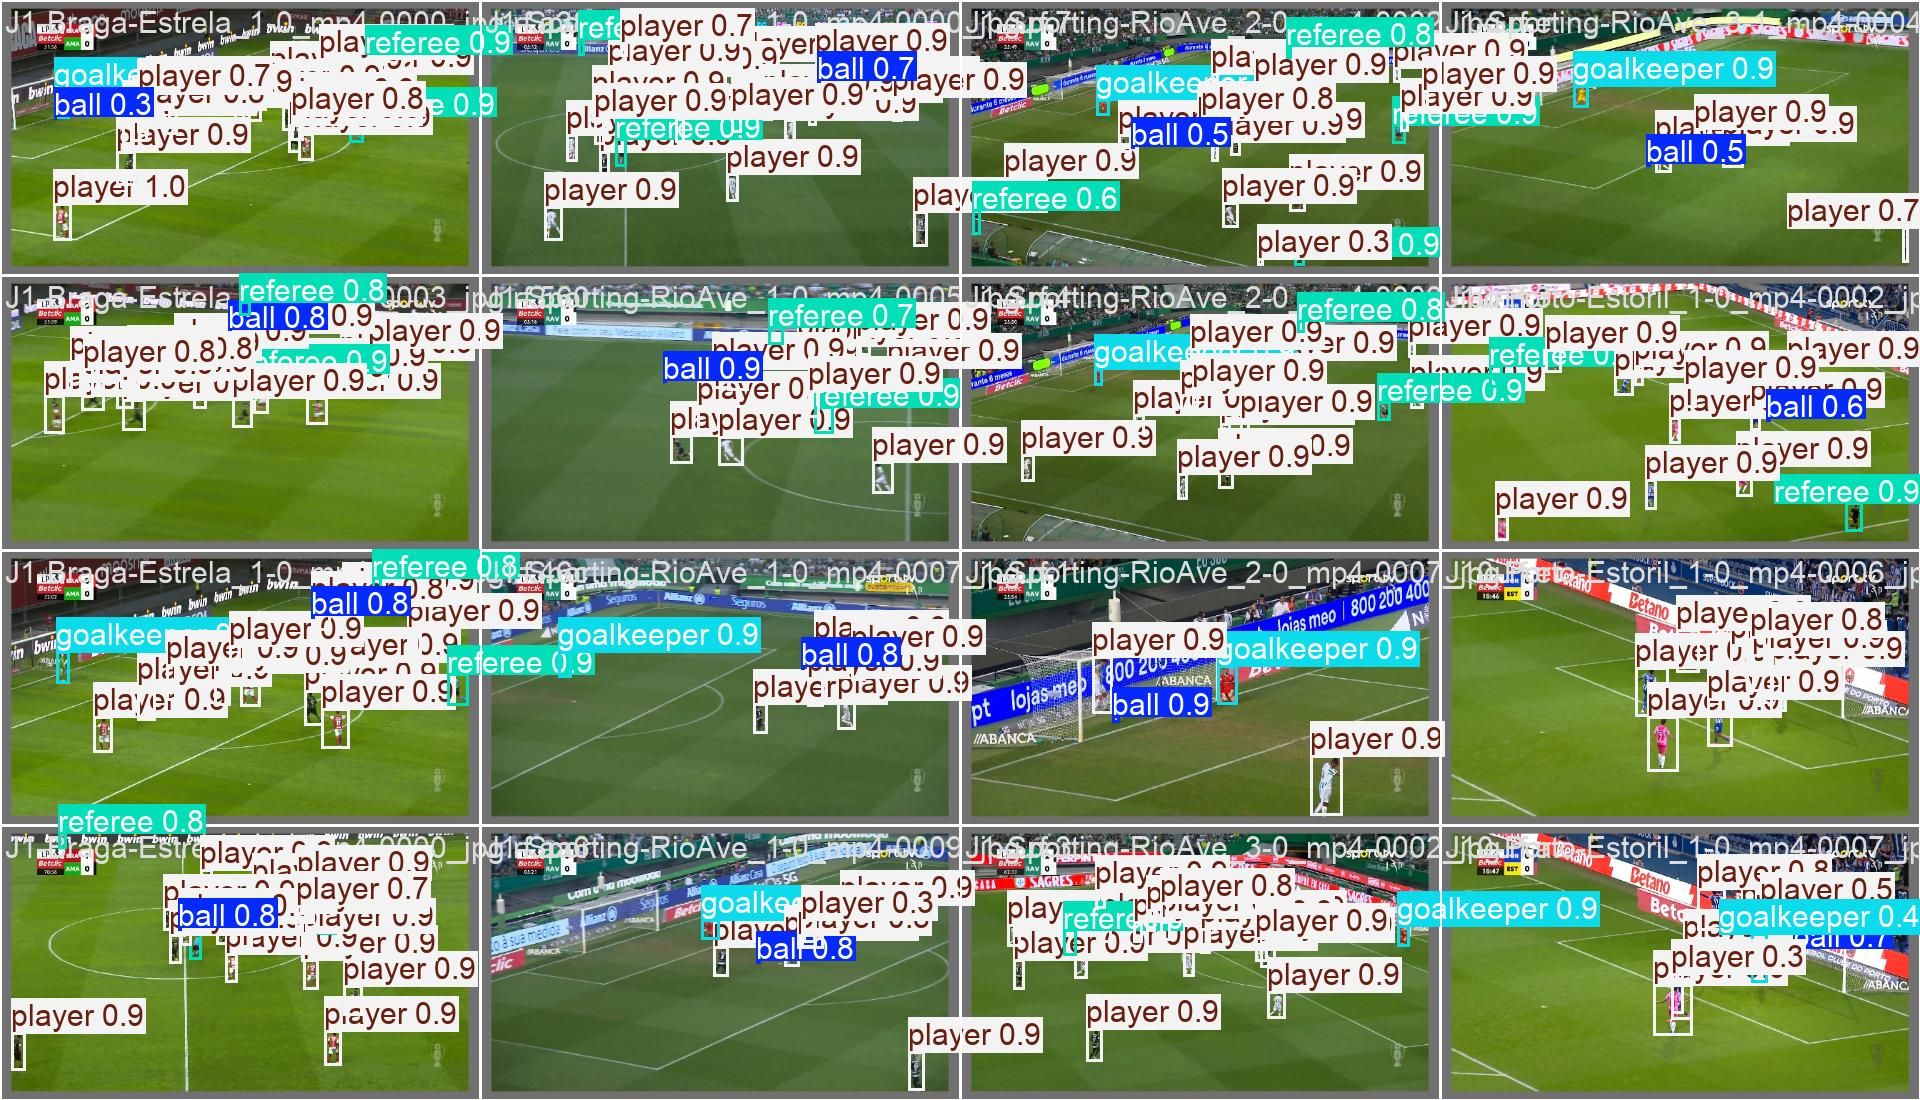

In [ ]:
from IPython.display import Image, display
# Mostra predições do batch de validação
display(Image(filename=f"{RUN_DIR}/val_batch0_pred.jpg", width=600))

## Validate custom model

In [ ]:
# Validação usando a API Python (evita problemas de CLI e paths com espaços)
# Usa mesma resolução do treino (1088) para consistência
metrics = model.val(data=DATA_YAML, imgsz=1088, batch=4, device=0, workers=4)
print(f"\n📊 MÉTRICAS FINAIS:")
print(f"mAP50:      {metrics.box.map50:.3f} ({metrics.box.map50*100:.1f}%)")
print(f"mAP50-95:   {metrics.box.map:.3f} ({metrics.box.map*100:.1f}%)")

Ultralytics 8.4.21  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv12m summary (fused): 169 layers, 20,107,996 parameters, 0 gradients, 67.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1900.6445.4 MB/s, size: 166.2 KB)
val: Scanning C:\_FOOTAR\PD_FOOTAR\training\datasets\football-players-and-ball\valid\labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 6.6it/s 4.0s0.1s
                   all        202       3194      0.938      0.853      0.882      0.731
                  ball        156        171      0.857      0.532      0.591      0.305
            goalkeeper        168        168      0.953      0.968      0.982      0.859
                player        202       2624      0.977      0.976      0.989      0.912
               referee        157        231      0.964      0.936   

In [ ]:
import shutil
import os
import csv

# Determina qual epoch usar (melhor ou último)
results_csv = os.path.join(RUN_DIR, "results.csv")
with open(results_csv, 'r') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

best_map50 = max(float(r['metrics/mAP50(B)']) for r in rows)
best_epoch = [i+1 for i, r in enumerate(rows) if float(r['metrics/mAP50(B)']) == best_map50][0]

# Caminhos
weights_dir = os.path.join(RUN_DIR, "weights")
best_weights = os.path.join(weights_dir, "best.pt")
data_dir = os.path.join(HOME, "..", "data")
os.makedirs(data_dir, exist_ok=True)

destination = os.path.join(data_dir, "yolo12m_jogadores_bola_1.pt")

# Copia
shutil.copy2(best_weights, destination)

print("=" * 60)
print("✅ MODELO COPIADO PARA PRODUÇÃO")
print("=" * 60)
print(f"Origem:  {best_weights}")
print(f"Destino: {destination}")
print(f"\n📝 PRÓXIMO PASSO:")
print(f"   Atualizar main.py para usar este modelo:")
print(f"   PLAYER_DETECTION_MODEL_PATH = 'data/yolo12m_jogadores_bola_1.pt'")
print(f"\n🎯 Melhor época foi: {best_epoch}")
if best_epoch < len(rows):
    print(f"   ⚠️ Se quiser usar epoch {best_epoch} especificamente:")
    epoch_file = f"epoch{best_epoch}.pt"
    if os.path.exists(os.path.join(weights_dir, epoch_file)):
        print(f"   Copiar: {os.path.join(weights_dir, epoch_file)}")
print("=" * 60)

✅ MODELO COPIADO PARA PRODUÇÃO
Origem:  C:\_FOOTAR\PD_FOOTAR\training\notebooks\runs\detect\runs\detect\yolo12m_jogadores_bola\weights\best.pt
Destino: c:\_FOOTAR\PD_FOOTAR\training\notebooks\..\data\yolo12m_jogadores_bola.pt

📝 PRÓXIMO PASSO:
   Atualizar main.py para usar este modelo:
   PLAYER_DETECTION_MODEL_PATH = 'data/yolo12m_jogadores_bola.pt'

🎯 Melhor época foi: 79
   ⚠️ Se quiser usar epoch 79 especificamente:


## Copy optimized model to production

Copia o modelo treinado `yolo12m_jogadores_bola.pt` para o diretório de modelos ativos.

In [ ]:
import shutil

# Copy the best trained model to models/active/ directory
SOURCE_MODEL = os.path.join(RUN_DIR, 'weights', 'best.pt')
TARGET_MODEL = r'C:\_FOOTAR\PD_FOOTAR\models\active\yolo12m_jogadores_bola_1.pt'

if os.path.exists(SOURCE_MODEL):
    shutil.copy2(SOURCE_MODEL, TARGET_MODEL)
    print(f"✅ Model copied to: {TARGET_MODEL}")
    print(f"📊 Model size: {os.path.getsize(TARGET_MODEL) / (1024**2):.1f} MB")
else:
    print(f"❌ Source model not found: {SOURCE_MODEL}")

# Summary
print("\n" + "="*60)
print("🎯 TRAINING SUMMARY - MODELO COMBINADO (Versão 1)")
print("="*60)
print(f"✅ Dataset: FOOTAR football-players-and-ball-1")
print(f"✅ Classes: 4 (ball, goalkeeper, player, referee)")
print(f"✅ Model: YOLOv12m (26M params)")
print(f"✅ Training config: batch=4, imgsz=1088, epochs=100")
print(f"✅ Augmentations: mosaic=1.0, mixup=0.1, copy_paste=0.1, scale=0.3")
print(f"✅ Best model: {TARGET_MODEL}")
print("="*60)

# Next steps
print("\n📌 PRÓXIMOS PASSOS:")
print("1. Verificar métricas mAP50 e mAP50-95")
print("2. Atualizar main.py para usar este modelo:")
print(f"   PLAYER_DETECTION_MODEL_PATH = 'models/active/yolo12m_jogadores_bola_1.pt'")
print("3. REMOVER o InferenceSlicer de bola do main.py")
print("4. Extrair bolas das deteções de jogadores (class_id == 0)")
print("5. Testar em modo RADAR - esperado: 15-25 FPS! 🚀")

✅ Model copied to: C:\_FOOTAR\PD_FOOTAR\models\active\yolo12m_jogadores_bola.pt
📊 Model size: 38.9 MB

🎯 TRAINING SUMMARY - MODELO COMBINADO
✅ Dataset: FOOTAR football-players-and-ball-1
✅ Classes: 4 (ball, goalkeeper, player, referee)
✅ Train images: 708
✅ Model: YOLOv12m (26M params)
✅ Training config: batch=8, imgsz=640, epochs=100
✅ Optimizer: SGD (lr0=0.01, momentum=0.937)
✅ Best model: C:\_FOOTAR\PD_FOOTAR\models\active\yolo12m_jogadores_bola.pt

📌 PRÓXIMOS PASSOS:
1. Verificar métricas mAP50 e mAP50-95
2. Atualizar main.py para usar este modelo:
   PLAYER_DETECTION_MODEL_PATH = 'models/active/yolo12m_jogadores_bola.pt'
3. REMOVER o InferenceSlicer de bola do main.py
4. Extrair bolas das deteções de jogadores (class_id == 0)
5. Testar em modo RADAR - esperado: 15-25 FPS! 🚀


## Optional: Deploy model on Roboflow (YOLOv8 only)

Note: Roboflow's deploy(model_type="yolov8") currently requires ultralytics==8.0.196. This notebook trains with YOLOv12 on ultralytics 8.3.x, so deploying from here will fail. You can:
- Upload the weights file manually in the Roboflow UI (Versions -> Upload Model -> YOLOv8) using RUN_DIR/weights/best.pt
- Or create a separate env with ultralytics==8.0.196 and run the deploy cell there.

In [ ]:
'''
# Guarded deploy: skip if ultralytics version is not the one required by Roboflow's deploy
import os
import ultralytics as ulx

# Resolve RUN_DIR and WEIGHTS path safely
try:
    RUN_DIR
except NameError:
    import glob
    base = os.path.join(HOME, "runs", "detect")
    # fallback: pick most recent detect run
    candidates = glob.glob(os.path.join(base, "*"))
    candidates = [p for p in candidates if os.path.isdir(p)]
    RUN_DIR = max(candidates, key=os.path.getmtime) if candidates else None

if RUN_DIR is None:
    print("No run directory found; train the model first.")
else:
    weights_path = os.path.join(RUN_DIR, "weights", "best.pt")
    need = "8.0.196"
    have = ulx.__version__
    if have == need:
        print(f"Deploying {weights_path} to Roboflow as YOLOv8 with ultralytics {have}...")
        project.version(dataset.version).deploy(model_type="yolov8", model_path=weights_path)
    else:
        print(f"Skipping deploy: Roboflow requires ultralytics=={need}, but found {have}.")
        print("Options:")
        print("  1) Upload manually in Roboflow UI: Versions -> Upload Model -> YOLOv8")
        print(f"     Weights: {weights_path}")
        print("  2) Create a separate env with ultralytics==8.0.196 and run this cell there.")


SyntaxError: incomplete input (3508607451.py, line 1)